In [2]:
%pip install --default-timeout=1000 torch torchvision --index-url https://download.pytorch.org/whl/cu123

Looking in indexes: https://download.pytorch.org/whl/cu123
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch

# بررسی اینکه آیا CUDA در دسترس است
print(f"Is CUDA available? {torch.cuda.is_available()}")

# اگر در دسترس است، نسخه آن را چاپ کن
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is NOT available. Please install the CUDA-enabled version of PyTorch.")

: 

In [11]:
from __future__ import print_function

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

from torchvision import datasets, transforms

In [24]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)

        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

In [13]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

In [14]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

        test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [25]:
use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available()

torch.manual_seed(42)

if use_cuda:
    device = torch.device("cuda")
elif use_mps:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

train_kwargs = {'batch_size': 64}
test_kwargs = {'batch_size': 1000}

if use_cuda:
    cuda_kwargs = {
        'num_workers': 1,
        'pin_memory': True,
        'shuffle': True
    }
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    'data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, **train_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

In [22]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"تعداد تصاویر در هر دسته (Batch Size): {images.shape[0]}")
print(
    f"تعداد کانال‌های تصویر (1 برای سیاه سفید، 3 برای رنگی): {images.shape[1]}")
print(f"ارتفاع تصویر (Height): {images.shape[2]}")
print(f"عرض تصویر (Width): {images.shape[3]}")
print(f"ابعاد کلی تنسور تصاویر: {images.shape}")
print(f"ابعاد لیبل‌ها: {labels.shape}")

# نمایش مقدار مینیمم و ماکزیمم پیکسل‌ها (برای چک کردن Normalize)
print(f"Min pixel value: {images.min().item():.4f}")
print(f"Max pixel value: {images.max().item():.4f}")

تعداد تصاویر در هر دسته (Batch Size): 64
تعداد کانال‌های تصویر (1 برای سیاه سفید، 3 برای رنگی): 1
ارتفاع تصویر (Height): 28
عرض تصویر (Width): 28
ابعاد کلی تنسور تصاویر: torch.Size([64, 1, 28, 28])
ابعاد لیبل‌ها: torch.Size([64])
Min pixel value: -0.4242
Max pixel value: 2.8215


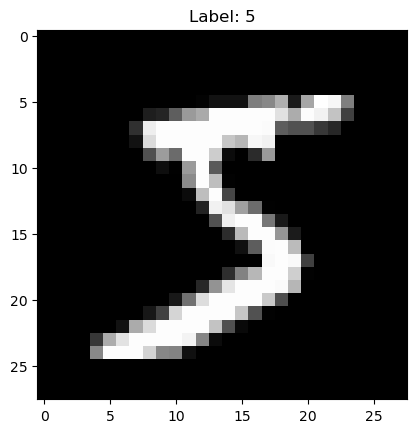

In [23]:
import matplotlib.pyplot as plt

# نمایش اولین تصویر از دسته
plt.imshow(images[0].numpy().squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [26]:
model = Net().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=1.0)

scheduler = StepLR(optimizer=optimizer, step_size=1, gamma=0.7)

for epoch in range(1, 20):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)
    scheduler.step()

checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
}
torch.save(checkpoint, "mnist_checkpoint.pt")

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.319619
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.503810
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.775642
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.490570
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.278325
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.332239
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.288198
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.312157
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.612316
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.316759
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.185096
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.202308
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.187797
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.175650
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.208073
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.191538
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.325236
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.228445
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.390648
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.197022
Train Epoch: 1 [12800/60000 (

NameError: name 'loss' is not defined